In [1]:
import pandas as pd
import numpy as np



In [2]:
df = pd.read_excel("CCL_dataset.xlsx")


In [3]:
df.shape

(963, 49)

In [4]:
df.isnull().sum()

Area Description                              0
Current Location                              0
Equipment category                            0
Object Type                                   0
Equipment                                     0
Manufacturer                                  0
Model number                                  1
CIL Number                                   11
ManufSerialNumber                             1
Capacity                                      0
Start-up date                                 0
CMPDI NORM (Availability)                     0
CMPDI Norm (Utilization)                      0
Progressive Shift Hours                       0
Progressive Work Hours                        0
Progressive Breakdown Hrs                     0
Progressive Maintenance Hrs                   0
Progressive Idle Hours                        0
Actual Progressive % Availability             0
Actual Progressive % Utilization              0
Prog Achievement to CMPDI NORM (Avail)  

## Data CLeaning

In [5]:
df.drop_duplicates(inplace=True)


In [6]:
date_cols = [
    'Start-up date',
    'Start Date',
    'End Date',
    'Breakdown Date',
    'Survey Off Date',
    'Warranty End date'
]

In [7]:
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')


In [10]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [12]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna("Unknown")



In [13]:
df.shape

(963, 49)

## Feature Engineering

In [14]:
today = pd.Timestamp.today()

df['Machine_Age_Years'] = (
    (today - df['Start-up date']).dt.days / 365
)

In [15]:
df['Breakdown_Ratio'] = (
    df['Progressive Breakdown Hrs']
    /
    (df['Progressive Shift Hours'] + 1)
)

In [16]:
df['Maintenance_Ratio'] = (
    df['Progressive Maintenance Hrs']
    /
    (df['Progressive Shift Hours'] + 1)
)

In [17]:
df['Availability_Gap'] = (
    df['CMPDI NORM (Availability)']
    -
    df['Actual Progressive % Availability']
)

In [18]:
MAX_LIFE = 15

df['Remaining_Life'] = (
    MAX_LIFE - df['Life Completed (in Yrs)']
)

## Target Creation

In [19]:
df['Critical'] = np.where(
    (
        (df['Life Completed (in Yrs)'] > 12)
        |
        (df['Actual Progressive % Availability'] < 70)
        |
        (df['Progressive Breakdown Hrs'] > 500)
    ),
    1,
    0
)

In [20]:
df['Service_Due'] = np.where(
    (
        (df['Progressive Maintenance Hrs'] > 300)
        |
        (df['Machine_Age_Years'] > 8)
    ),
    1,
    0
)

In [21]:
df['Failure_Risk'] = np.where(
    (
        (df['Breakdown_Ratio'] > 0.10)
        |
        (df['Actual Progressive % Availability'] < 75)
    ),
    1,
    0
)

## EDA

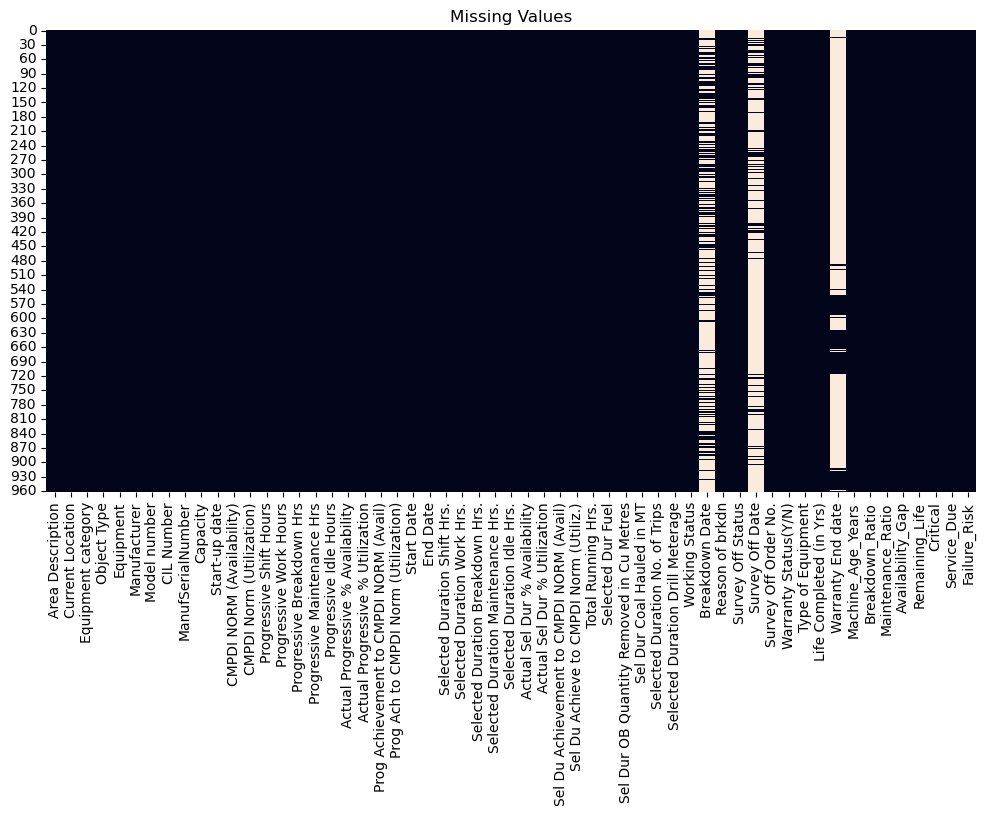

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

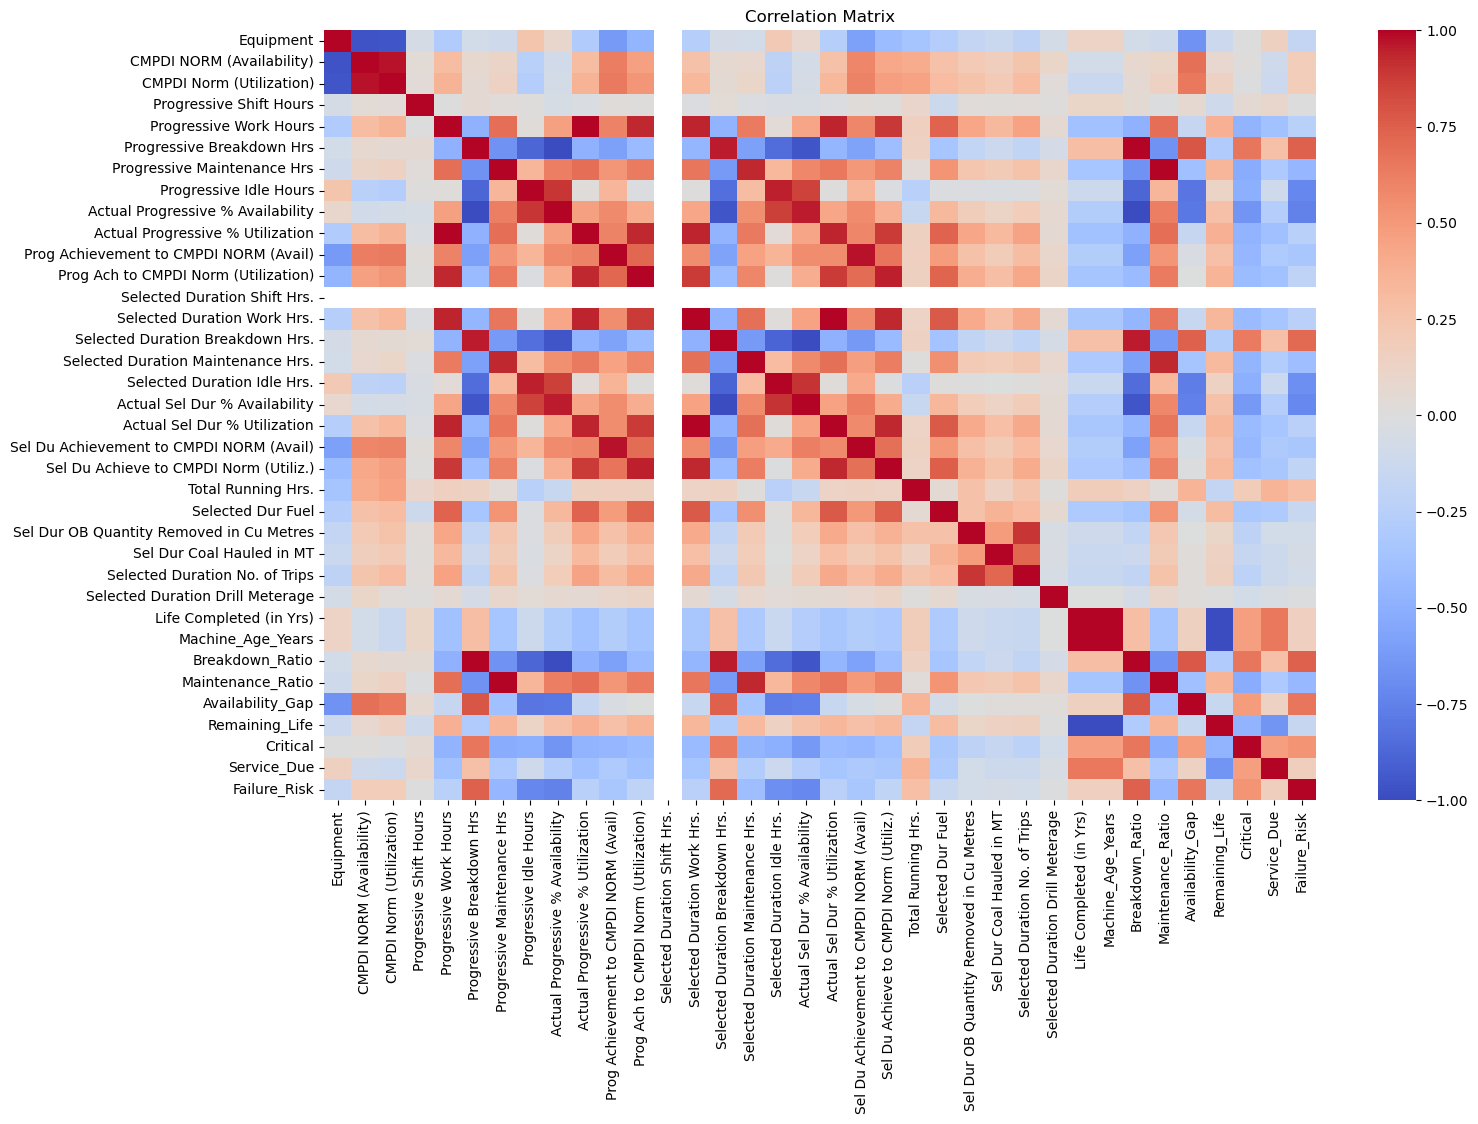

In [23]:
plt.figure(figsize=(16,10))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Matrix")
plt.show()

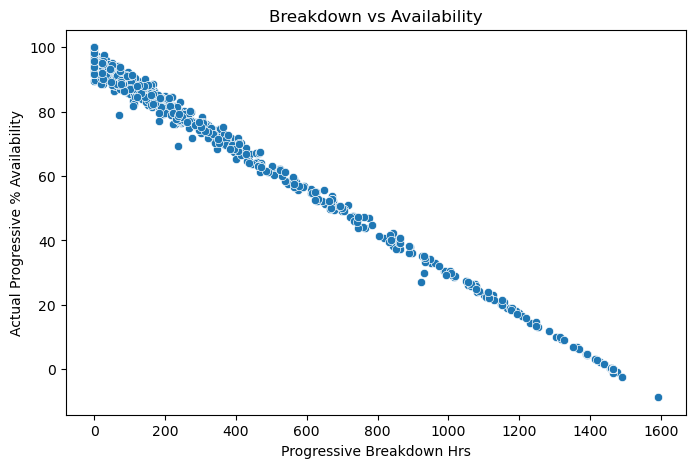

In [24]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Progressive Breakdown Hrs',
    y='Actual Progressive % Availability'
)

plt.title("Breakdown vs Availability")
plt.show()

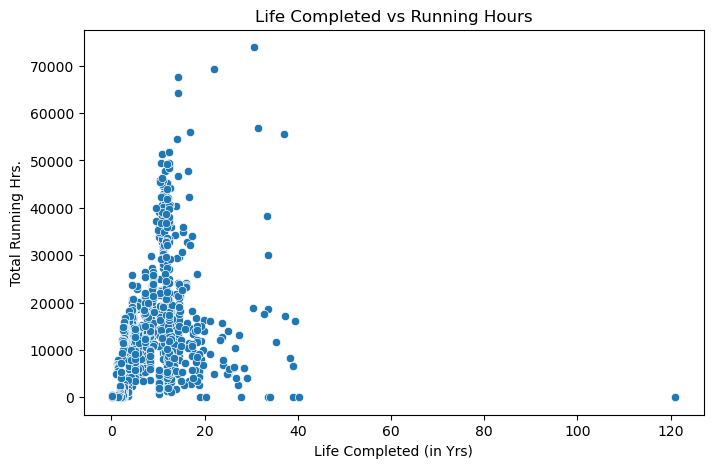

In [25]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Life Completed (in Yrs)',
    y='Total Running Hrs.'
)

plt.title("Life Completed vs Running Hours")
plt.show()

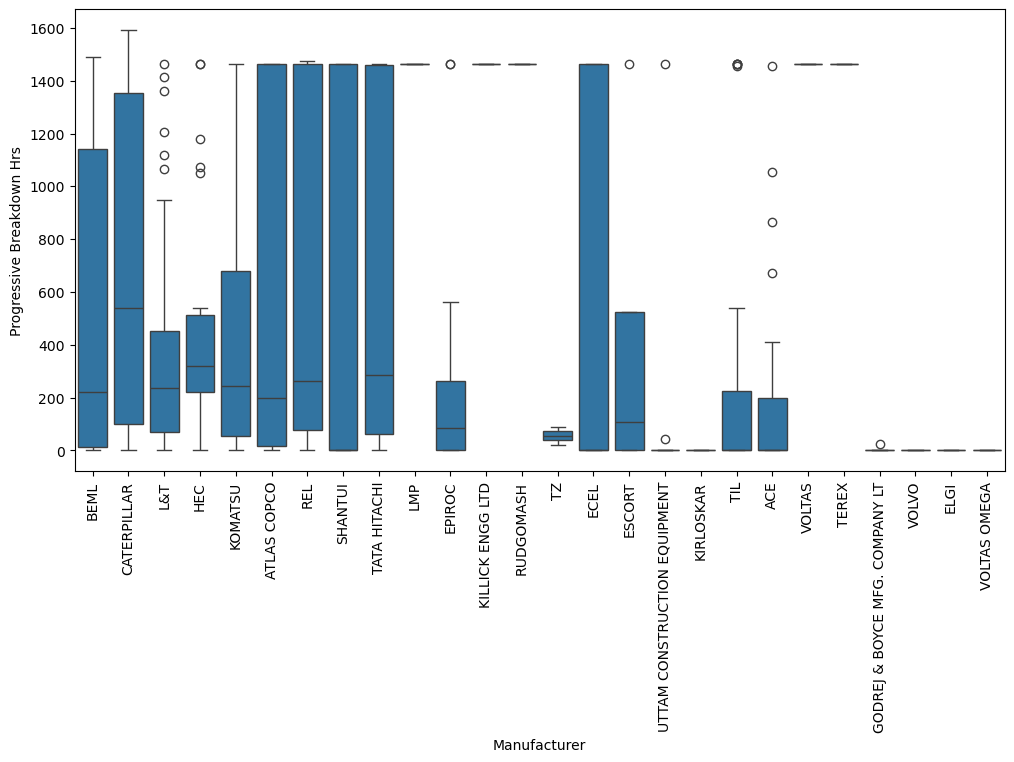

In [26]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='Manufacturer',
    y='Progressive Breakdown Hrs'
)

plt.xticks(rotation=90)
plt.show()

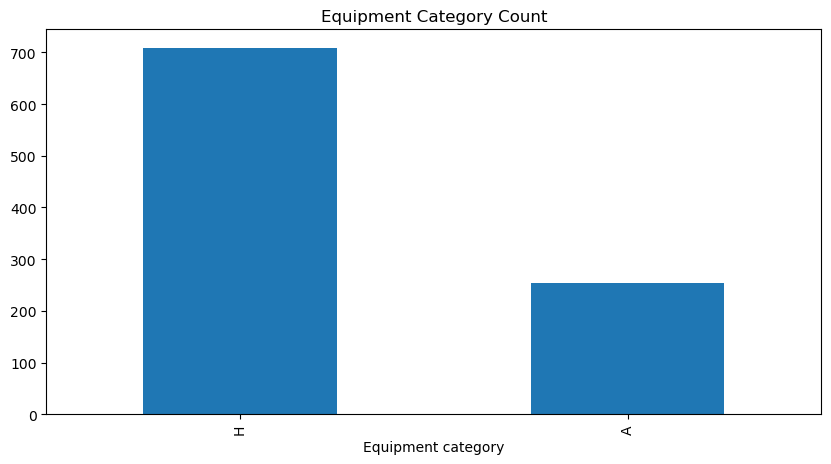

In [27]:
plt.figure(figsize=(10,5))

df['Equipment category'].value_counts().plot(
    kind='bar'
)

plt.title("Equipment Category Count")
plt.show()

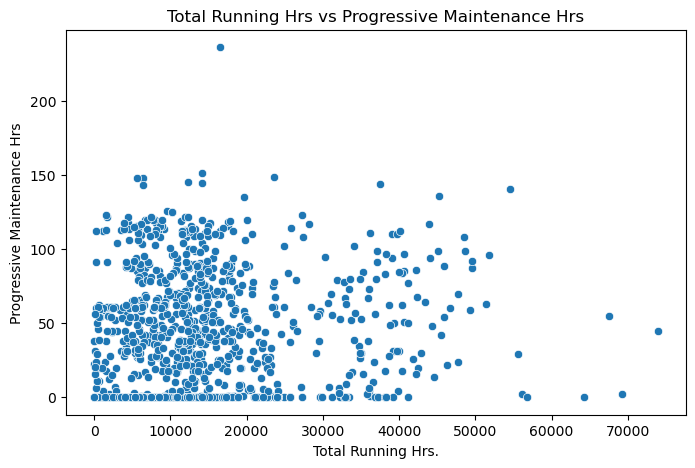

In [28]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Total Running Hrs.',
    y='Progressive Maintenance Hrs',
    data=df
)
plt.title("Total Running Hrs vs Progressive Maintenance Hrs")
plt.show()

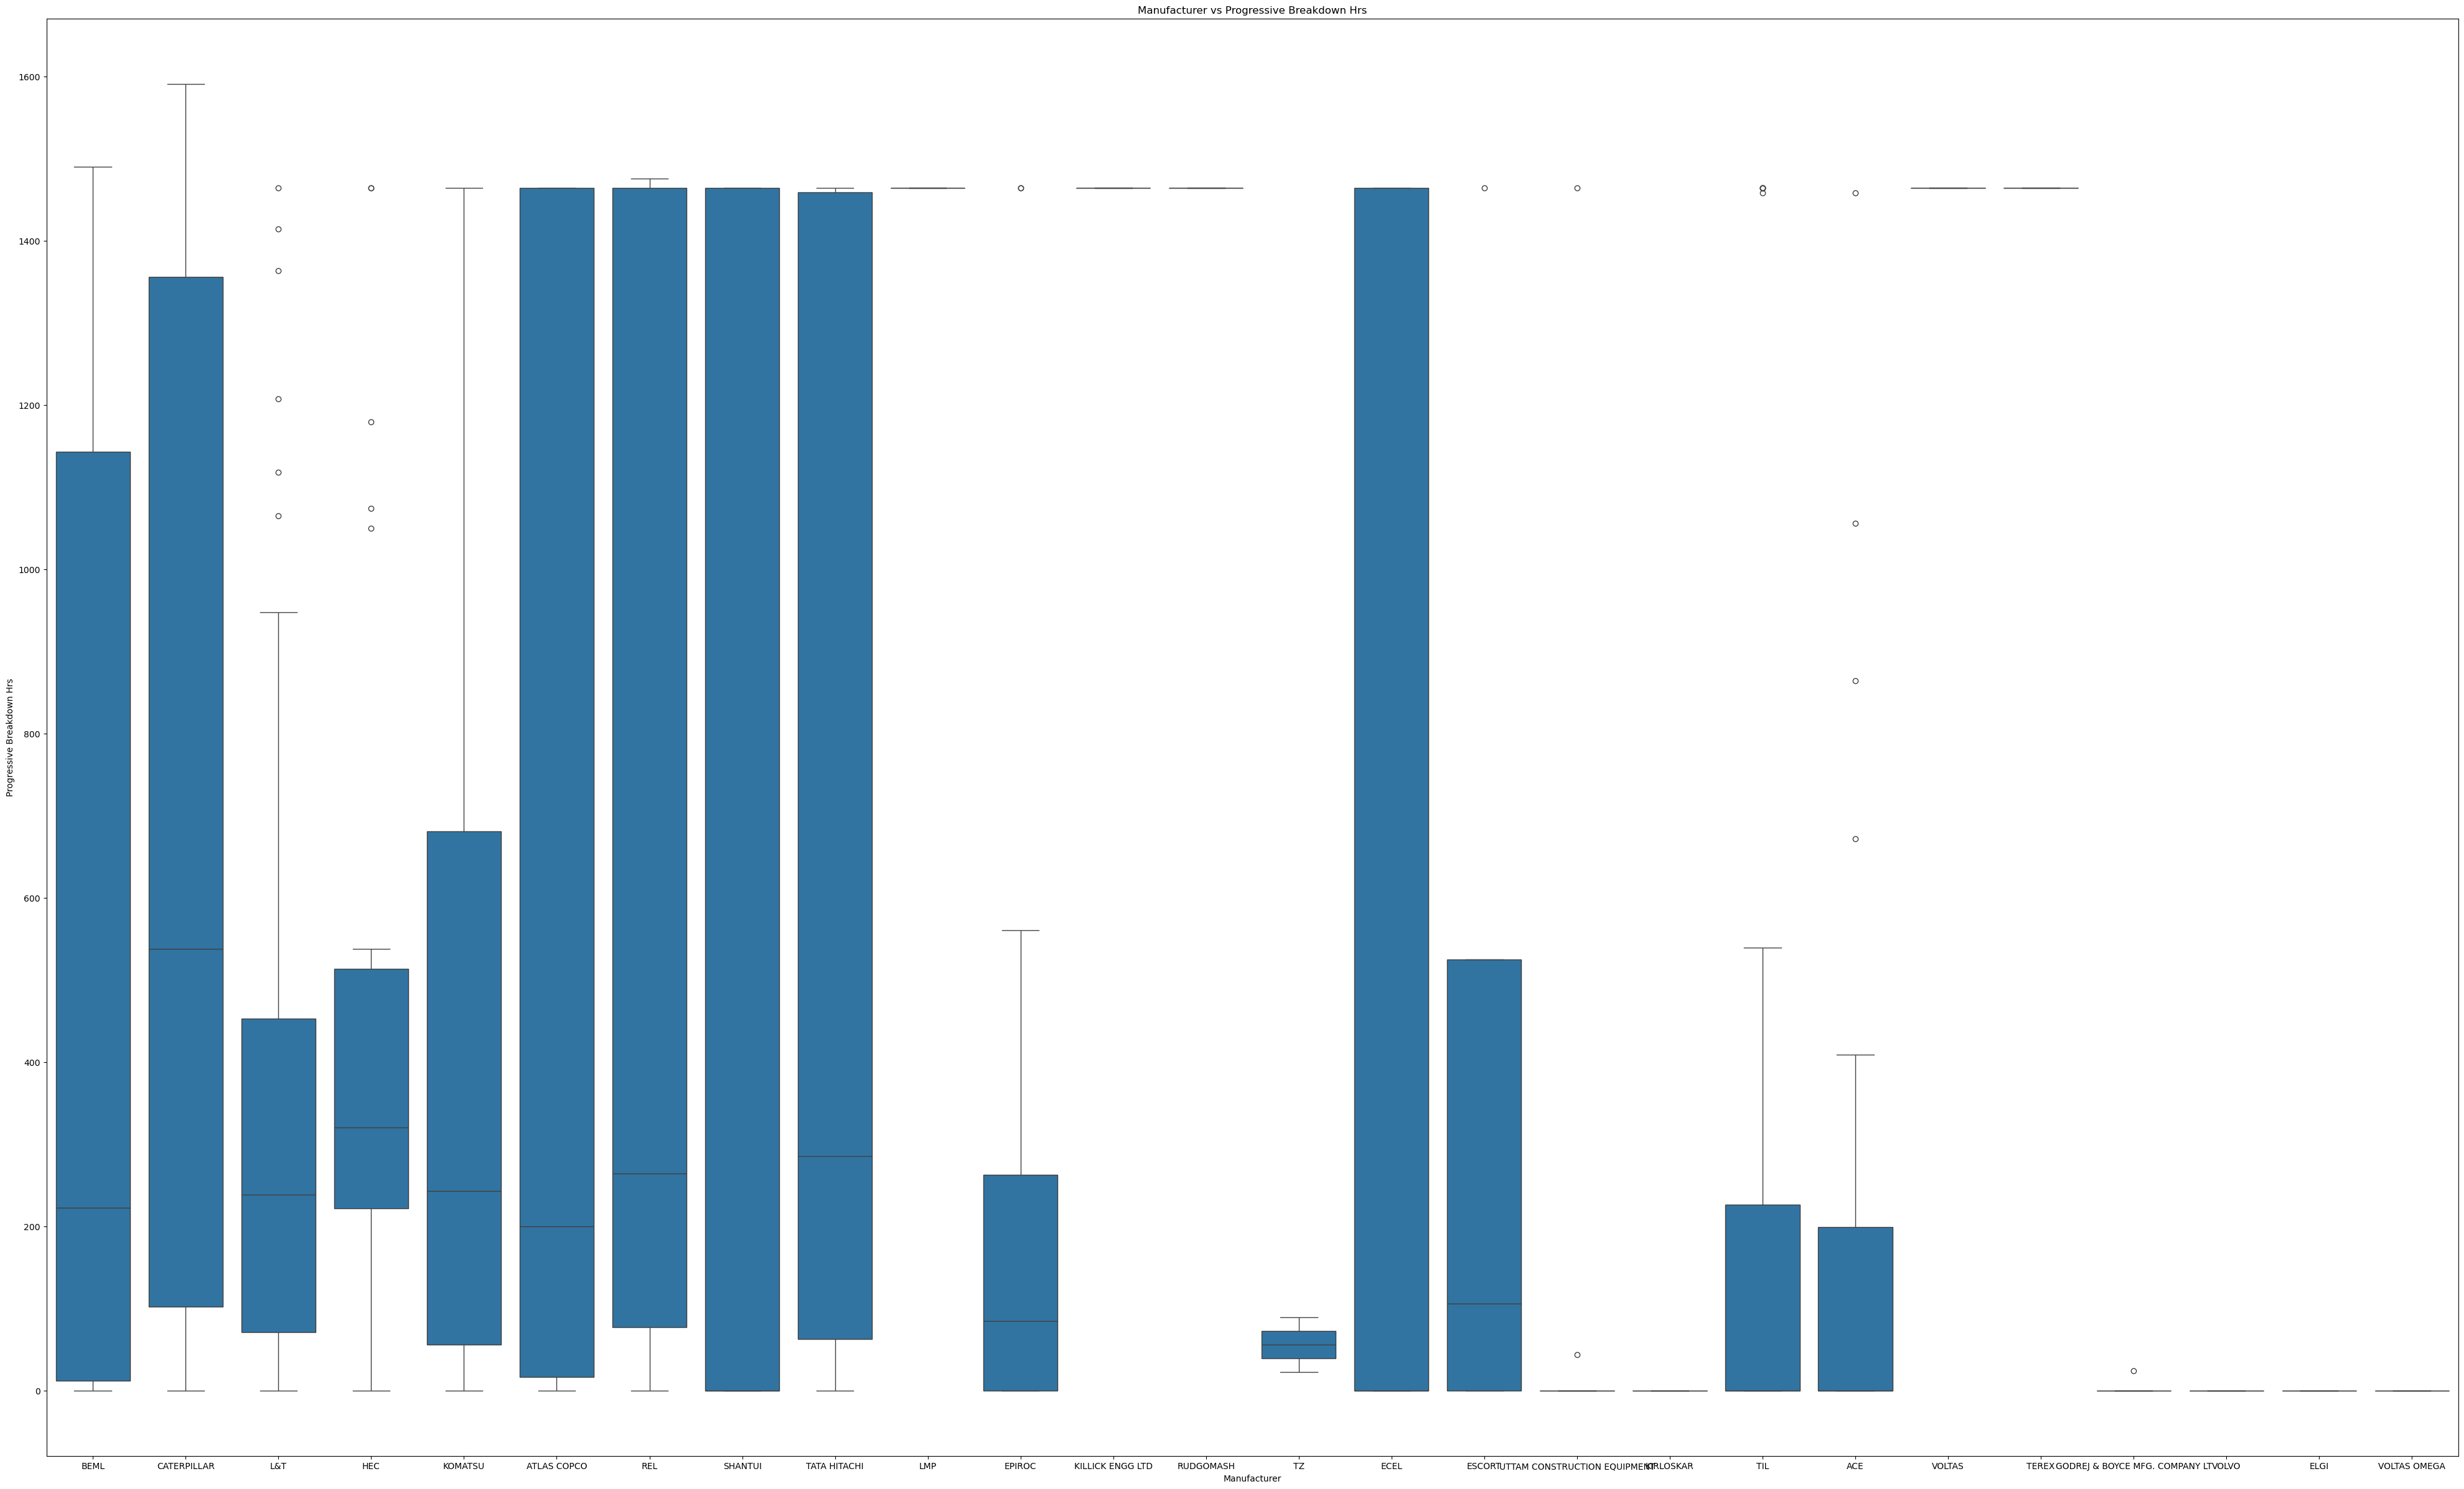

In [34]:
plt.figure(figsize=(50,30))

sns.boxplot(
    x='Manufacturer',
    y='Progressive Breakdown Hrs',
    data=df
)

plt.title("Manufacturer vs Progressive Breakdown Hrs")
plt.show()

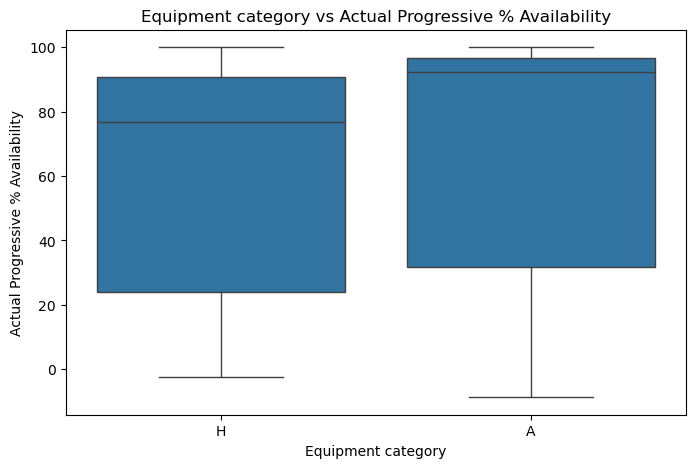

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Equipment category',
    y='Actual Progressive % Availability',
    data=df
)
plt.title("Equipment category vs Actual Progressive % Availability")
plt.show()